# Market Intelligence & Host Segmentation

В этом ноутбуке pricing-модель используется как аналитический слой поверх уже обученного ансамбля: она помогает сравнить фактические цены с ожидаемыми рыночными значениями, найти потенциально недооценённые и переоценённые listings, оценить близость цены к model-based benchmark и приблизительно посчитать revenue potential.

Во второй части данные агрегируются на уровне `host_id`, после чего сравниваются два подхода к сегментации хостов: `KMeans` как основной интерпретируемый метод и `HDBSCAN` как density-based sanity check для поиска нестандартных хостов и outliers.

**Input:** processed datasets + trained ensemble model из `models/`  
**Output:** `data/processed/listings_classified.csv`, `data/processed/hosts_segmented.csv`, segmentation models в `models/`


## Setup


In [1]:
# Базовые настройки и загрузка моделей
import os, json, pickle, warnings
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
import plotly.express as px
import catboost as cb
import lightgbm as lgb
import xgboost as xgb

try:
    import hdbscan
    HAS_HDBSCAN = True
except ImportError:
    HAS_HDBSCAN = False

try:
    import umap
    HAS_UMAP, UMAP_IMPORT_ERROR = True, None
except Exception as exc:
    HAS_UMAP, UMAP_IMPORT_ERROR = False, exc

SEED = 42
np.random.seed(SEED)
sns.set_theme(style="whitegrid", context="notebook")

PROCESSED = Path("../data/processed")
MODELS = Path("../models")

lf = pd.read_parquet(PROCESSED / "listings_features.parquet").reset_index(drop=True)

with open(MODELS / "cat_cols.json") as f:
    CAT_COLS = json.load(f)
with open(MODELS / "ensemble_weights.json") as f:
    ENS = json.load(f)

cat_model = cb.CatBoostRegressor()
cat_model.load_model(str(MODELS / "catboost_pricing.cbm"))
lgb_model = lgb.Booster(model_file=str(MODELS / "lightgbm_pricing.txt"))
xgb_model = xgb.Booster()
xgb_model.load_model(str(MODELS / "xgboost_pricing.json"))

print(f"listings: {lf.shape}")
print(f"cat_cols: {CAT_COLS}")
print(f"ensemble weights: {ENS['weights']}")


listings: (5844, 107)
cat_cols: ['host_is_superhost', 'host_has_profile_pic', 'host_identity_verified', 'neighbourhood_cleansed', 'instant_bookable', 'property_type_grp']
ensemble weights: {'cat': 0.3398838004373828, 'lgb': 0.32345264627306874, 'xgb': 0.33666355328954856}


## Market Intelligence


### Undervalued / Overpriced Detector

- `residual = actual_price - predicted_price`
- `residual_z` считается внутри района, чтобы сравнение учитывало локальный уровень цен
- `undervalued`: `residual_z < -1.5`, фактическая цена заметно ниже model-based benchmark
- `overpriced`: `residual_z > 1.5`, фактическая цена заметно выше model-based benchmark
- Ratings используются только как sanity check: они не доказывают инвестиционную привлекательность, но помогают отсеять часть очевидного шума


In [2]:
# Готовим фичи в том же формате, что и в nb03
FEAT_COLS = pd.read_parquet(PROCESSED / "X_train.parquet").columns.tolist()
X_all = lf[FEAT_COLS].copy()

for col in CAT_COLS:
    X_all[col] = X_all[col].fillna("unknown").astype(str)

X_tree = X_all.copy()
for col in CAT_COLS:
    X_tree[col] = X_tree[col].astype("category")

pred = {
    "cat": cat_model.predict(X_all),
    "lgb": lgb_model.predict(X_tree),
    "xgb": xgb_model.predict(xgb.DMatrix(X_tree, enable_categorical=True)),
}
weights = ENS["weights"]
lf["predicted_price"] = np.expm1(sum(weights[name] * pred[name] for name in pred))

print(f"mean actual    : {lf['price'].mean():.1f} EUR")
print(f"mean predicted : {lf['predicted_price'].mean():.1f} EUR")


mean actual    : 257.3 EUR
mean predicted : 246.2 EUR


In [3]:
# Остаток нормализуем внутри района, чтобы убрать location bias
lf["residual"] = lf["price"] - lf["predicted_price"]
by_neighbourhood = lf.groupby("neighbourhood_cleansed")["residual"]
lf["residual_z"] = (
    (lf["residual"] - by_neighbourhood.transform("mean"))
    / by_neighbourhood.transform("std").replace(0, np.nan)
)

display(lf[["price", "predicted_price", "residual", "residual_z"]].describe().round(2))


,price,predicted_price,residual,residual_z
count,5844.00,5844.00,5844.00,5844.00
mean,257.28,246.18,11.10,0.00
std,153.23,117.96,72.72,1.00
min,35.00,40.18,-302.90,-4.09
25%,161.00,171.10,-25.46,-0.52
50%,221.00,222.15,-0.06,-0.16
75%,310.00,294.00,30.87,0.30
max,1410.00,1148.84,909.03,9.83


In [4]:
# Разметка по локальному z-score
CATEGORY_ORDER = ["undervalued", "fair", "overpriced"]
lf["category"] = np.select(
    [lf["residual_z"].lt(-1.5), lf["residual_z"].gt(1.5), lf["residual_z"].isna()],
    ["undervalued", "overpriced", "unknown"],
    default="fair",
)

print(lf["category"].value_counts())


category
fair           5336
overpriced      371
undervalued     137
Name: count, dtype: int64


#### Графики: категории, residuals и price gap


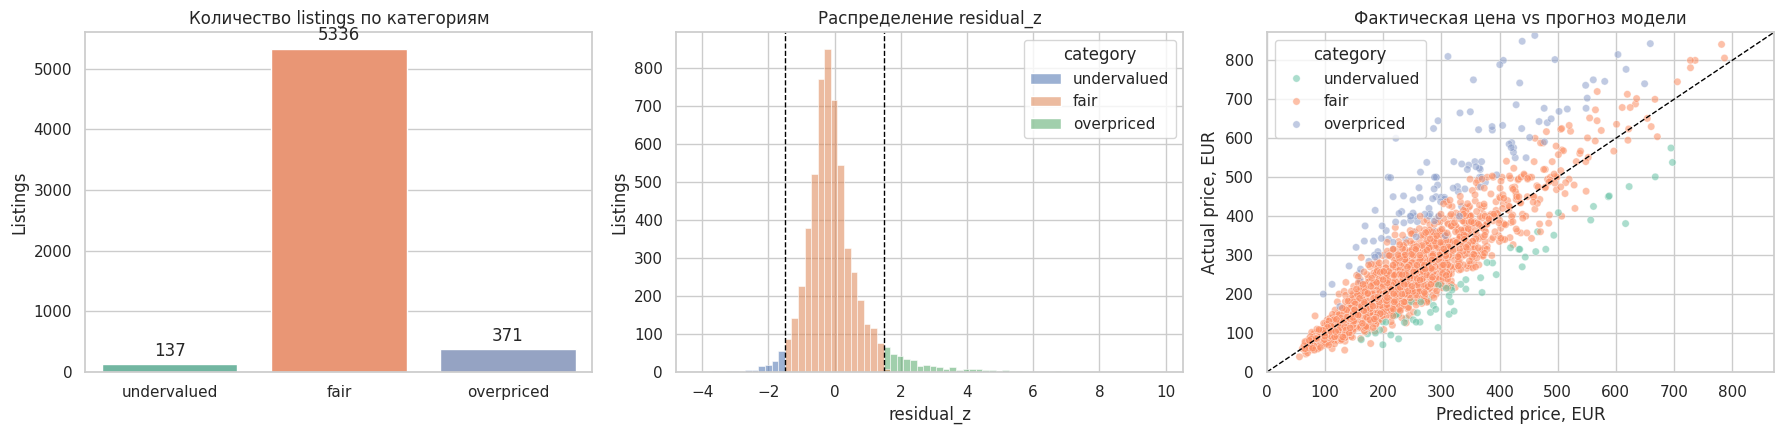

In [5]:
# Быстрая проверка распределений и price gap
plot_df = lf[lf["category"].isin(CATEGORY_ORDER)].copy()
sample = plot_df.sample(min(len(plot_df), 2500), random_state=SEED)
limit = lf[["price", "predicted_price"]].quantile(0.99).max()

fig, ax = plt.subplots(1, 3, figsize=(18, 4.5))

sns.countplot(data=plot_df, x="category", order=CATEGORY_ORDER, palette="Set2", ax=ax[0])
ax[0].set(title="Количество listings по категориям", xlabel="", ylabel="Listings")
for bars in ax[0].containers:
    ax[0].bar_label(bars, fmt="%.0f", padding=3)

sns.histplot(
    data=plot_df,
    x="residual_z",
    hue="category",
    hue_order=CATEGORY_ORDER,
    bins=70,
    common_norm=False,
    alpha=0.55,
    ax=ax[1],
)
ax[1].axvline(-1.5, color="black", linestyle="--", linewidth=1)
ax[1].axvline(1.5, color="black", linestyle="--", linewidth=1)
ax[1].set(title="Распределение residual_z", xlabel="residual_z", ylabel="Listings")

sns.scatterplot(
    data=sample,
    x="predicted_price",
    y="price",
    hue="category",
    hue_order=CATEGORY_ORDER,
    palette="Set2",
    alpha=0.55,
    s=28,
    ax=ax[2],
)
ax[2].plot([0, limit], [0, limit], color="black", linestyle="--", linewidth=1)
ax[2].set(
    title="Фактическая цена vs прогноз модели",
    xlabel="Predicted price, EUR",
    ylabel="Actual price, EUR",
    xlim=(0, limit),
    ylim=(0, limit),
)

plt.tight_layout()
plt.show()


In [6]:
# Top undervalued и sanity-check по рейтингам
under_cols = [
    "id", "neighbourhood_cleansed", "price", "predicted_price",
    "residual_z", "review_scores_rating", "number_of_reviews",
]
top_under = lf[lf["category"].eq("undervalued")].nsmallest(100, "residual_z")
ratings = lf.groupby("category")["review_scores_rating"].agg(["mean", "median", "count"])

print("Топ-15 undervalued:")
display(top_under[under_cols].head(15).round(2))
print("Рейтинги по категориям (sanity check):")
display(ratings.round(2))


Топ-15 undervalued:


,id,neighbourhood_cleansed,price,predicted_price,residual_z,review_scores_rating,number_of_reviews
1600,34110514,Westerpark,381.0,616.74,-4.09,4.83,12
4419,1205624647807772760,Bijlmer-Centrum,95.0,212.95,-3.60,1.00,1
2345,554197353421997470,Centrum-West,382.0,684.90,-3.58,4.63,8
954,18233200,IJburg - Zeeburgereiland,247.0,494.79,-3.49,4.72,198
3431,947950161643739184,Noord-Oost,315.0,479.52,-3.29,NaN,0
569,8395119,De Pijp - Rivierenbuurt,291.0,520.50,-3.23,4.80,64
770,14022135,Oud-Noord,346.0,531.57,-3.03,4.73,330
2912,788138401782921530,Centrum-Oost,850.0,1097.89,-2.91,5.00,10
1248,24276106,Centrum-West,150.0,383.68,-2.80,5.00,29
1086,21145986,Geuzenveld - Slotermeer,280.0,388.01,-2.69,4.90,10


Рейтинги по категориям (sanity check):


,mean,median,count
category,,,
fair,4.84,4.91,4751
overpriced,4.87,4.96,327
undervalued,4.83,4.92,121


#### Графики: undervalued по районам


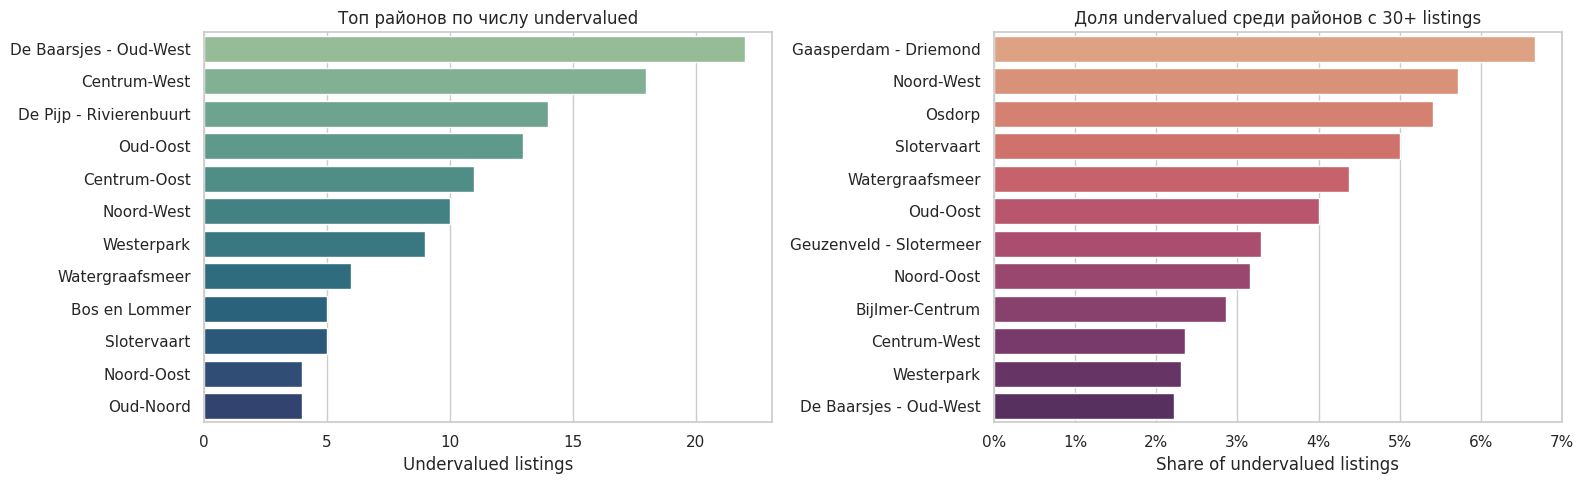

,listings,undervalued,undervalued_share,median_residual_z,median_price
neighbourhood_cleansed,,,,,
De Baarsjes - Oud-West,991,22,0.022,-0.173,240.0
Centrum-West,765,18,0.024,-0.182,244.0
De Pijp - Rivierenbuurt,648,14,0.022,-0.137,250.0
Oud-Oost,325,13,0.040,-0.132,222.0
Centrum-Oost,577,11,0.019,-0.140,239.0
Noord-West,175,10,0.057,-0.104,180.0
Westerpark,390,9,0.023,-0.155,214.0
Watergraafsmeer,137,6,0.044,-0.135,212.0
Bos en Lommer,261,5,0.019,-0.176,184.0


In [7]:
# Undervalued по районам: абсолютное число и доля
nb_stats = (
    lf.assign(is_undervalued=lf["category"].eq("undervalued"))
    .groupby("neighbourhood_cleansed")
    .agg(
        listings=("id", "count"),
        undervalued=("is_undervalued", "sum"),
        undervalued_share=("is_undervalued", "mean"),
        median_residual_z=("residual_z", "median"),
        median_price=("price", "median"),
    )
    .query("listings >= 30")
    .sort_values("undervalued", ascending=False)
)

fig, ax = plt.subplots(1, 2, figsize=(16, 5))
sns.barplot(data=nb_stats.head(12).reset_index(), y="neighbourhood_cleansed", x="undervalued", palette="crest", ax=ax[0])
ax[0].set(title="Топ районов по числу undervalued", xlabel="Undervalued listings", ylabel="")

share_top = nb_stats.sort_values("undervalued_share", ascending=False).head(12).reset_index()
sns.barplot(data=share_top, y="neighbourhood_cleansed", x="undervalued_share", palette="flare", ax=ax[1])
ax[1].set(title="Доля undervalued среди районов с 30+ listings", xlabel="Share of undervalued listings", ylabel="")
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))

plt.tight_layout()
plt.show()
display(nb_stats.head(10).round(3))


#### Вывод: undervalued / overpriced detector

На основе `residual_z` listings были разделены на три категории:
- `undervalued` — 137 объектов;
- `fair` — 5336 объектов;
- `overpriced` — 371 объект.

Большинство listings относятся к категории `fair`: их фактическая цена близка к prediction модели. Экстремальные отклонения (`|z| > 1.5`) встречаются относительно редко.

**Sanity check по рейтингам**

Средние ratings оказались очень близкими между категориями:
- `undervalued`: `4.83`;
- `fair`: `4.84`;
- `overpriced`: `4.87`.

Это слабый sanity check: рейтинги не подтверждают сильного качества undervalued-сегмента как отдельной группы. При этом среди top undervalued listings есть объекты с высокими ratings и большим количеством reviews, поэтому detector всё равно полезен как список кандидатов для ручного market analysis.

**Районы с наибольшим числом undervalued listings**

По текущему snapshot больше всего undervalued listings найдено в:
- `De Baarsjes - Oud-West`;
- `Centrum-West`;
- `De Pijp - Rivierenbuurt`.

Эти районы одновременно имеют высокий объём listings, поэтому абсолютное число undervalued объектов стоит читать вместе с долей undervalued внутри района.


### Market Fairness Score

- `fairness_score = 1 / (1 + |residual_z|)` принимает значения ближе к `1`, когда цена близка к model-based benchmark
- Top fair-priced listings используются как benchmark рынка, а не как утверждение об «идеальной» цене


In [8]:
# Близость цены к model-based benchmark
lf["fairness_score"] = 1 / (1 + lf["residual_z"].abs())
top_fair = lf.nlargest(100, "fairness_score")

print("Топ-15 fair-priced (benchmark рынка):")
display(top_fair[["id", "neighbourhood_cleansed", "price", "predicted_price", "fairness_score"]].head(15).round(3))
print("Median fairness по категориям:")
print(lf.groupby("category")["fairness_score"].median().round(3))


Топ-15 fair-priced (benchmark рынка):


,id,neighbourhood_cleansed,price,predicted_price,fairness_score
1445,30265278,Centrum-West,158.0,141.311,1.000
2967,808662624466713575,Centrum-Oost,702.0,689.840,1.000
2260,52849571,Centrum-West,294.0,277.277,0.999
4684,1268824738891959438,Westerpark,162.0,154.992,0.999
660,11133575,Noord-West,155.0,153.240,0.999
2450,628205795256250116,De Pijp - Rivierenbuurt,350.0,341.770,0.999
2767,736254837518595490,Buitenveldert - Zuidas,220.0,210.307,0.999
3001,831022223464858161,Buitenveldert - Zuidas,162.0,152.294,0.999
3029,843999435584135990,De Baarsjes - Oud-West,432.0,420.334,0.998
12,193038,Centrum-Oost,158.0,145.977,0.998


Median fairness по категориям:
category
fair           0.714
overpriced     0.307
undervalued    0.359
Name: fairness_score, dtype: float64


#### Графики: fairness score


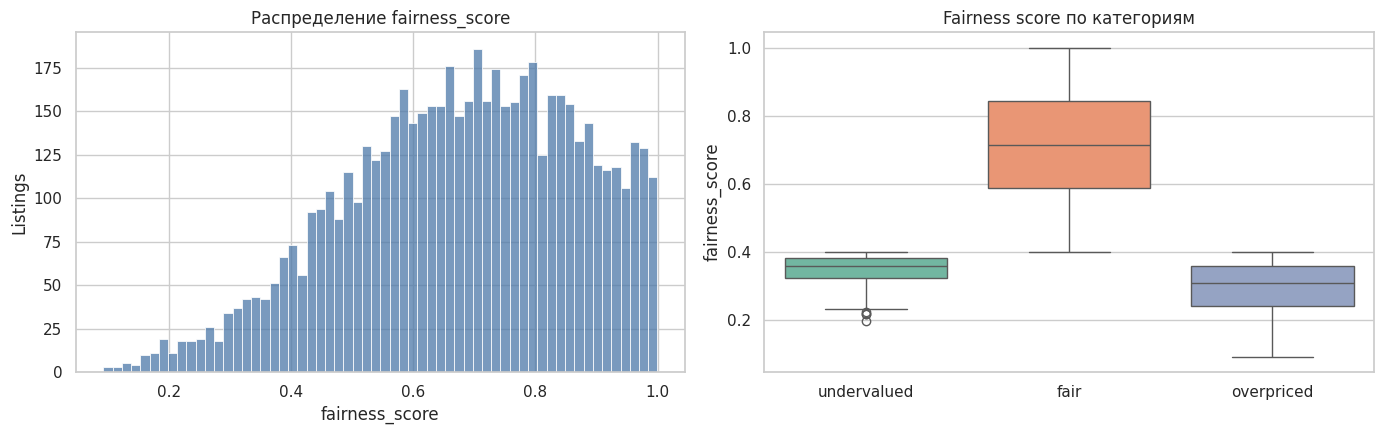

In [9]:
# Распределение fairness score
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))

sns.histplot(lf["fairness_score"].dropna(), bins=60, color="#4C78A8", ax=ax[0])
ax[0].set(title="Распределение fairness_score", xlabel="fairness_score", ylabel="Listings")

sns.boxplot(
    data=lf[lf["category"].isin(CATEGORY_ORDER)],
    x="category",
    y="fairness_score",
    order=CATEGORY_ORDER,
    palette="Set2",
    ax=ax[1],
)
ax[1].set(title="Fairness score по категориям", xlabel="", ylabel="fairness_score")

plt.tight_layout()
plt.show()


#### Вывод: market fairness score

`fairness_score` показывает близость фактической цены к ожидаемой цене модели. Медианный score у `fair` listings заметно выше, чем у `undervalued` и `overpriced`, что подтверждает согласованность метрики с классификацией по `residual_z`.

Top fair-priced listings можно использовать как практический benchmark:
- для новых хостов — как ориентир рыночной цены;
- для сравнения собственного listing с похожими объектами;
- как baseline для dynamic pricing или рекомендаций в Streamlit-приложении.

Важно: высокий fairness score не означает «лучшую» цену или высокий спрос. Он показывает только то, что текущая цена близка к цене, ожидаемой моделью для похожих listings.


### Revenue Potential

- `revenue_potential = price x calendar_unavail_rate x 365`
- `calendar_unavail_rate` используется как occupancy proxy, а не как точная занятость
- Метрика оценивает приблизительный upper-bound revenue potential, а не реальную выручку
- Дополнительно проверяются топ-районы и связь с location features


In [10]:
# Потенциал: price x proxy занятости x 365, не фактическая выручка
lf["revenue_potential"] = lf["price"] * lf["calendar_unavail_rate"] * 365
print(lf["revenue_potential"].describe().round(0))


count      5844.0
mean      51789.0
std       43103.0
min           0.0
25%       19740.0
50%       44620.0
75%       72320.0
max      463915.0
Name: revenue_potential, dtype: float64


In [11]:
# Топ районов и связь с location features
top_nb = (
    lf.groupby("neighbourhood_cleansed")
    .agg(
        listings=("id", "count"),
        median_price=("price", "median"),
        median_occupancy=("calendar_unavail_rate", "median"),
        median_revenue=("revenue_potential", "median"),
    )
    .sort_values("median_revenue", ascending=False)
    .head(5)
)
loc_cols = ["distance_to_center", "is_tourist_zone", "neighborhood_listing_density"]
corr = lf[["revenue_potential", *loc_cols]].corr().iloc[0, 1:].round(3)

print("Топ-5 районов по медианной выручке:")
display(top_nb.round(2))
print("Корреляция revenue_potential с location-фичами:")
print(corr)


Топ-5 районов по медианной выручке:


,listings,median_price,median_occupancy,median_revenue
neighbourhood_cleansed,,,,
De Baarsjes - Oud-West,991,240.0,0.73,52200.0
Zuid,431,237.0,0.65,50160.0
De Pijp - Rivierenbuurt,648,250.0,0.60,47046.0
Centrum-West,765,244.0,0.65,46500.0
Westerpark,390,214.0,0.68,46092.0


Корреляция revenue_potential с location-фичами:
distance_to_center             -0.110
is_tourist_zone                 0.052
neighborhood_listing_density    0.106
Name: revenue_potential, dtype: float64


#### Графики: revenue potential


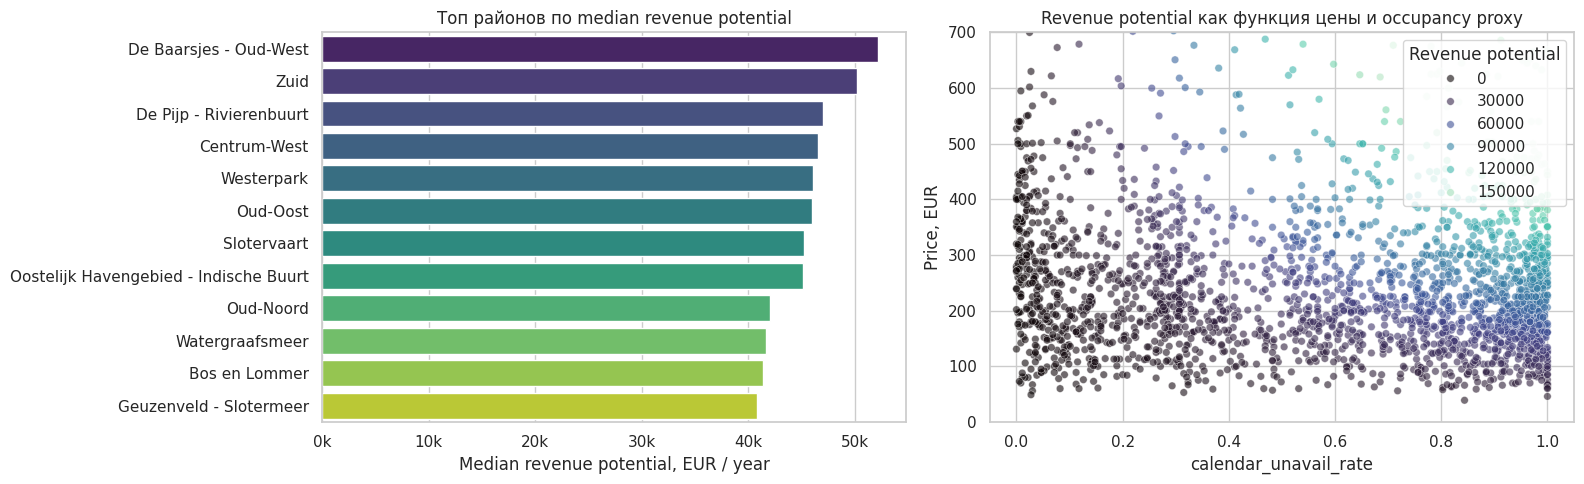

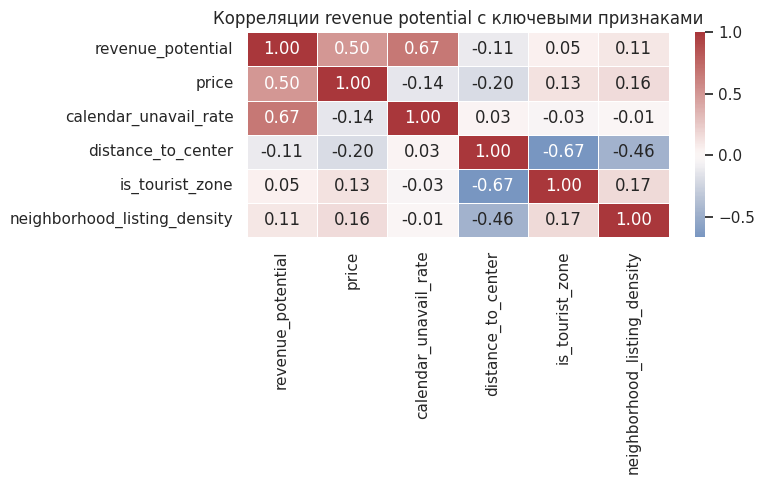

In [12]:
# Revenue potential: районы, цена, proxy занятости и корреляции
revenue_nb = (
    lf.groupby("neighbourhood_cleansed")
    .agg(
        listings=("id", "count"),
        median_price=("price", "median"),
        median_occupancy=("calendar_unavail_rate", "median"),
        median_revenue=("revenue_potential", "median"),
    )
    .query("listings >= 30")
    .sort_values("median_revenue", ascending=False)
    .head(12)
    .reset_index()
)

fig, ax = plt.subplots(1, 2, figsize=(16, 5))
sns.barplot(data=revenue_nb, y="neighbourhood_cleansed", x="median_revenue", palette="viridis", ax=ax[0])
ax[0].set(title="Топ районов по median revenue potential", xlabel="Median revenue potential, EUR / year", ylabel="")
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))

sample = lf.sample(min(len(lf), 2500), random_state=SEED).copy()
sample["revenue_capped"] = sample["revenue_potential"].clip(upper=lf["revenue_potential"].quantile(0.98))
sns.scatterplot(
    data=sample,
    x="calendar_unavail_rate",
    y="price",
    hue="revenue_capped",
    palette="mako",
    alpha=0.6,
    s=30,
    ax=ax[1],
)
ax[1].set(
    title="Revenue potential как функция цены и occupancy proxy",
    xlabel="calendar_unavail_rate",
    ylabel="Price, EUR",
    ylim=(0, lf["price"].quantile(0.98)),
)
ax[1].legend(title="Revenue potential", loc="upper right")
plt.tight_layout()
plt.show()

corr_cols = ["revenue_potential", "price", "calendar_unavail_rate", *loc_cols]
plt.figure(figsize=(8, 5))
sns.heatmap(lf[corr_cols].corr(), annot=True, fmt=".2f", cmap="vlag", center=0, linewidths=0.5)
plt.title("Корреляции revenue potential с ключевыми признаками")
plt.tight_layout()
plt.show()


#### Вывод: revenue potential

Средний `revenue_potential` по listings составил примерно `51.8k EUR` в год, но распределение очень неравномерное: дорогие объекты и listings с высоким `calendar_unavail_rate` дают значительно больший оценочный потенциал.

**Топ районов по median revenue potential**

- `De Baarsjes - Oud-West` — около `52.2k EUR`;
- `Zuid` — около `50.2k EUR`;
- `De Pijp - Rivierenbuurt` — около `47.0k EUR`;
- `Centrum-West` — около `46.5k EUR`;
- `Westerpark` — около `46.1k EUR`.

Эти районы сочетают относительно высокие nightly prices, высокий unavailability proxy и большой объём активных listings.

**Корреляция с location features**

Корреляции слабые, но логичные по знаку:
- `distance_to_center`: `r = -0.11`;
- `is_tourist_zone`: `r = +0.05`;
- `neighborhood_listing_density`: `r = +0.11`.

Это означает, что более центральные объекты, tourist-зоны и плотные Airbnb-районы слегка связаны с более высоким revenue potential. Однако сила связи небольшая: revenue potential определяется не только location, но и ценой, типом жилья, размером объекта и availability pattern.

**Ограничение метрики**

`revenue_potential` — это не реальная выручка, а приближённая upper-bound оценка:

```text
price x occupancy_proxy x 365
```

Для Амстердама это особенно важно: regulatory cap и особенности календаря означают, что `calendar_unavail_rate` нельзя напрямую читать как фактическую occupancy.


## Host Segmentation

На этом этапе listings агрегируются на уровне хоста, чтобы сегментировать не отдельные объекты, а стратегии поведения host accounts. Основной метод — `KMeans`, потому что его сегменты проще интерпретировать и использовать в downstream dashboard. `HDBSCAN` используется как дополнительная проверка плотностной структуры и outliers.


### Признаки для кластеризации

Агрегаты по `host_id`:
- `host_listings_count`;
- `host_experience_years`;
- `mean_price` — средняя цена объектов хоста;
- `median_unavail_rate` — медианный availability/unavailability proxy;
- `is_superhost`;
- `host_response_rate`.


In [13]:
# Переходим с listings на уровень host_id
hf = (
    lf.groupby("host_id")
    .agg(
        host_listings_count=("host_listings_count", "first"),
        host_experience_years=("host_experience_years", "first"),
        mean_price=("price", "mean"),
        median_unavail_rate=("calendar_unavail_rate", "median"),
        is_superhost=("host_is_superhost", lambda s: int(str(s.iloc[0]).lower() in {"t", "true", "1"})),
        host_response_rate=("host_response_rate", "first"),
    )
    .reset_index()
    .dropna(subset=["host_listings_count", "host_experience_years", "mean_price", "median_unavail_rate"])
)

print(f"hosts: {hf.shape}")
display(hf.describe().round(2))


hosts: (5026, 7)


,host_id,host_listings_count,host_experience_years,mean_price,median_unavail_rate,is_superhost,host_response_rate
count,5.026000e+03,5026.00,5026.00,5026.00,5026.00,5026.00,4206.00
mean,1.309796e+08,1.87,9.19,262.21,0.60,0.22,0.90
std,1.780816e+08,17.15,3.38,151.26,0.33,0.41,0.24
min,3.592000e+03,1.00,0.02,49.33,0.00,0.00,0.00
25%,1.202754e+07,1.00,7.54,167.00,0.30,0.00,1.00
50%,4.430060e+07,1.00,9.97,225.00,0.69,0.00,1.00
75%,1.747962e+08,1.00,11.56,315.00,0.91,0.00,1.00
max,7.173470e+08,957.00,16.91,1410.00,1.00,1.00,1.00


In [14]:
# Масштабируем признаки перед clustering
feat_cols = [
    "host_listings_count", "host_experience_years", "mean_price",
    "median_unavail_rate", "is_superhost", "host_response_rate",
]
X = hf[feat_cols].fillna(hf[feat_cols].median())
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"X_scaled: {X_scaled.shape}")


X_scaled: (5026, 6)


### KMeans

- Elbow и silhouette используются для выбора `k`
- Метрики: `inertia`, `silhouette_score`
- Финальный `k` выбирается не только по максимуму метрики, но и по интерпретируемости сегментов


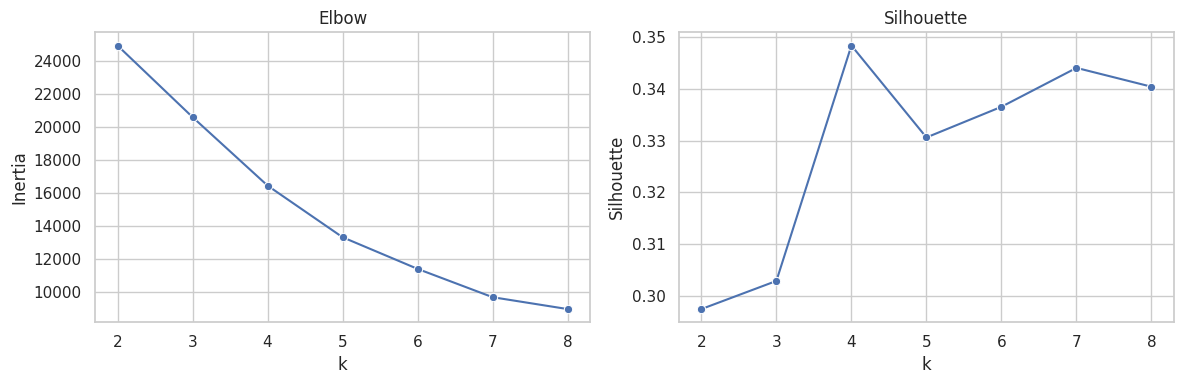

  k=2  silhouette=0.297
  k=3  silhouette=0.303
  k=4  silhouette=0.348
  k=5  silhouette=0.331
  k=6  silhouette=0.337
  k=7  silhouette=0.344
  k=8  silhouette=0.340


In [15]:
# Подбираем k по elbow и silhouette
ks = range(2, 9)
scores = []
for k in ks:
    model = KMeans(n_clusters=k, random_state=SEED, n_init=10).fit(X_scaled)
    scores.append({"k": k, "inertia": model.inertia_, "silhouette": silhouette_score(X_scaled, model.labels_)})

k_scores = pd.DataFrame(scores)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.lineplot(data=k_scores, x="k", y="inertia", marker="o", ax=ax[0])
sns.lineplot(data=k_scores, x="k", y="silhouette", marker="o", ax=ax[1])
ax[0].set(title="Elbow", xlabel="k", ylabel="Inertia")
ax[1].set(title="Silhouette", xlabel="k", ylabel="Silhouette")
plt.tight_layout()
plt.show()

for row in k_scores.itertuples(index=False):
    print(f"  k={row.k}  silhouette={row.silhouette:.3f}")


In [16]:
# Финальная KMeans-сегментация
K = 4
km = KMeans(n_clusters=K, random_state=SEED, n_init=10).fit(X_scaled)
hf["cluster_kmeans"] = km.labels_

print(hf["cluster_kmeans"].value_counts().sort_index())
print(f"silhouette: {silhouette_score(X_scaled, km.labels_):.3f}   inertia: {km.inertia_:.1f}")


cluster_kmeans
0    1089
1    3528
2     406
3       3
Name: count, dtype: int64


silhouette: 0.348   inertia: 16448.1


#### Вывод: KMeans

Для KMeans выбран `k = 4`.

Выбор основан на сочетании:
- `elbow method` — после `k≈4-5` снижение inertia становится менее резким;
- `silhouette score` — максимум достигается при `k=4` (`0.348`);
- бизнес-интерпретируемости сегментов.

Финальный результат:
- `silhouette score = 0.348`;
- `inertia = 16448.1`.

Размеры кластеров распределены неравномерно:
- один крупный массовый сегмент (`3528` хостов);
- два средних сегмента (`1089` и `406` хостов);
- один очень маленький сегмент (`3` хоста), похожий на extreme professional / commercial accounts.

Silhouette около `0.35` говорит об умеренно выраженной структуре: сегменты различаются, но между ними остаётся пересечение, что нормально для marketplace data.


### HDBSCAN

- `HDBSCAN(min_cluster_size=50)` используется как density-based альтернатива
- Метод не требует заранее выбирать `k`
- `cluster = -1` интерпретируется как outliers/noise


In [17]:
# HDBSCAN: density-based проверка и outliers
if HAS_HDBSCAN:
    hdb = hdbscan.HDBSCAN(min_cluster_size=50, metric="euclidean")
    hf["cluster_hdbscan"] = hdb.fit_predict(X_scaled)

    n_clusters = hf.loc[hf["cluster_hdbscan"].ne(-1), "cluster_hdbscan"].nunique()
    outliers_pct = hf["cluster_hdbscan"].eq(-1).mean() * 100

    print("HDBSCAN кластеры (-1 = outliers):")
    print("clusters:", n_clusters)
    print(f"outliers: {outliers_pct:.1f}% хостов")
    display(hf["cluster_hdbscan"].value_counts(dropna=False).sort_index())
else:
    hdb = None
    hf["cluster_hdbscan"] = -1
    print("hdbscan не установлен - секция пропущена")


HDBSCAN кластеры (-1 = outliers):
clusters: 2
outliers: 1.4% хостов


cluster_hdbscan
-1      71
 0    1066
 1    3889
Name: count, dtype: int64

#### Вывод: HDBSCAN

HDBSCAN обнаружил `2` основных кластера хостов:
- cluster `0` — 1066 хостов;
- cluster `1` — 3889 хостов.

Дополнительно `71` хост (`1.4%`) были помечены как `outliers` (`cluster = -1`).

Такой процент outliers выглядит низким для real-world marketplace data: большинство хостов имеют типичное поведение, а HDBSCAN выделяет только небольшую группу нестандартных аккаунтов.

Вероятные outliers:
- крупные professional hosts;
- дорогие niche/luxury listings;
- редкие хосты с необычным сочетанием occupancy proxy, pricing и portfolio size.

HDBSCAN нашёл меньше сегментов, чем KMeans, поэтому он полезен скорее как sanity check и outlier detector, а не как финальная бизнес-сегментация.


### Сравнение методов

Сравниваются:
- число найденных кластеров;
- доля outliers;
- silhouette score;
- интерпретируемость результата для market analysis.


In [18]:
# Сравниваем методы одинаковыми метриками
rows = []
for method, col in [("KMeans", "cluster_kmeans"), ("HDBSCAN", "cluster_hdbscan")]:
    mask = hf[col].ne(-1)
    labels = hf.loc[mask, col]
    sil = silhouette_score(X_scaled[mask.values], labels) if mask.sum() > 10 and labels.nunique() > 1 else np.nan
    rows.append({
        "method": method,
        "n_clusters": int(labels.nunique()),
        "outliers_pct": round(hf[col].eq(-1).mean() * 100, 1),
        "silhouette": round(sil, 3) if pd.notna(sil) else None,
    })

display(pd.DataFrame(rows))


,method,n_clusters,outliers_pct,silhouette
0,KMeans,4,0.0,0.348
1,HDBSCAN,2,1.4,0.310


#### Графики: сравнение методов


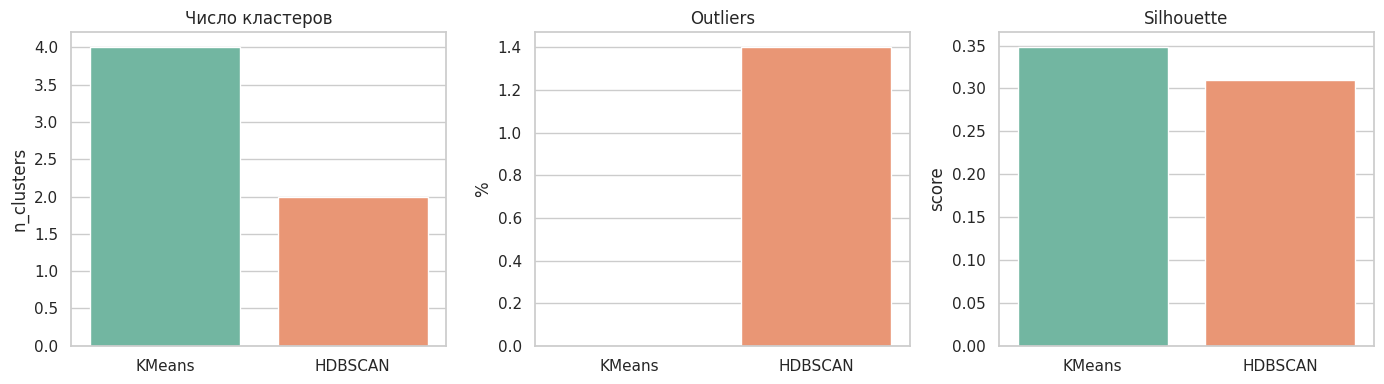

In [19]:
# Визуальное сравнение методов
comparison_df = pd.DataFrame(rows)
metrics = [
    ("n_clusters", "Число кластеров", "n_clusters"),
    ("outliers_pct", "Outliers", "%"),
    ("silhouette", "Silhouette", "score"),
]

fig, ax = plt.subplots(1, 3, figsize=(14, 4))
for axis, (col, title, ylabel) in zip(ax, metrics):
    sns.barplot(data=comparison_df, x="method", y=col, palette="Set2", ax=axis)
    axis.set(title=title, xlabel="", ylabel=ylabel)

plt.tight_layout()
plt.show()


#### Вывод: сравнение методов

По итоговым метрикам `KMeans` показал немного лучшее качество кластеризации:
- `silhouette = 0.348`;
- против `0.310` у HDBSCAN.

Кроме того, KMeans дал более детальные и интерпретируемые сегменты: mainstream hosts, experienced superhosts, low activity hosts и small commercial/operator group.

HDBSCAN полезен для поиска atypical hosts и outliers, но нашёл только `2` основных кластера. Поэтому финальным методом выбран `KMeans`: он лучше подходит для dashboard, бизнес-объяснения и downstream-рекомендаций.


### Интерпретация кластеров

Финальные labels задаются вручную по профилям кластеров. Это осознанный шаг: автоматические номера KMeans не имеют бизнес-смысла сами по себе.


In [20]:
# Профилируем KMeans-кластеры медианами
cluster_names = {
    0: "experienced_superhosts",
    1: "mainstream_hosts",
    2: "low_activity_hosts",
    3: "commercial_operators",
}

profile = hf.groupby("cluster_kmeans").agg(
    n_hosts=("host_id", "count"),
    host_listings_count=("host_listings_count", "median"),
    host_experience_years=("host_experience_years", "median"),
    median_price=("mean_price", "median"),
    median_unavail_rate=("median_unavail_rate", "median"),
    is_superhost=("is_superhost", "mean"),
    host_response_rate=("host_response_rate", "median"),
)
profile["label"] = profile.index.map(cluster_names)
hf["final_label"] = hf["cluster_kmeans"].map(cluster_names)

print("Профили кластеров:")
display(profile.round(2))
print()
print("Итоговые сегменты:")
print(hf["final_label"].value_counts())


Профили кластеров:


,n_hosts,host_listings_count,host_experience_years,median_price,median_unavail_rate,is_superhost,host_response_rate,label
cluster_kmeans,,,,,,,,
0,1089,1.0,10.12,189.0,0.62,1.0,1.00,experienced_superhosts
1,3528,1.0,9.97,237.0,0.75,0.0,1.00,mainstream_hosts
2,406,1.0,9.69,223.5,0.37,0.0,0.25,low_activity_hosts
3,3,569.0,4.08,241.5,0.07,0.0,1.00,commercial_operators



Итоговые сегменты:
final_label
mainstream_hosts          3528
experienced_superhosts    1089
low_activity_hosts         406
commercial_operators         3
Name: count, dtype: int64


#### Графики: профили сегментов


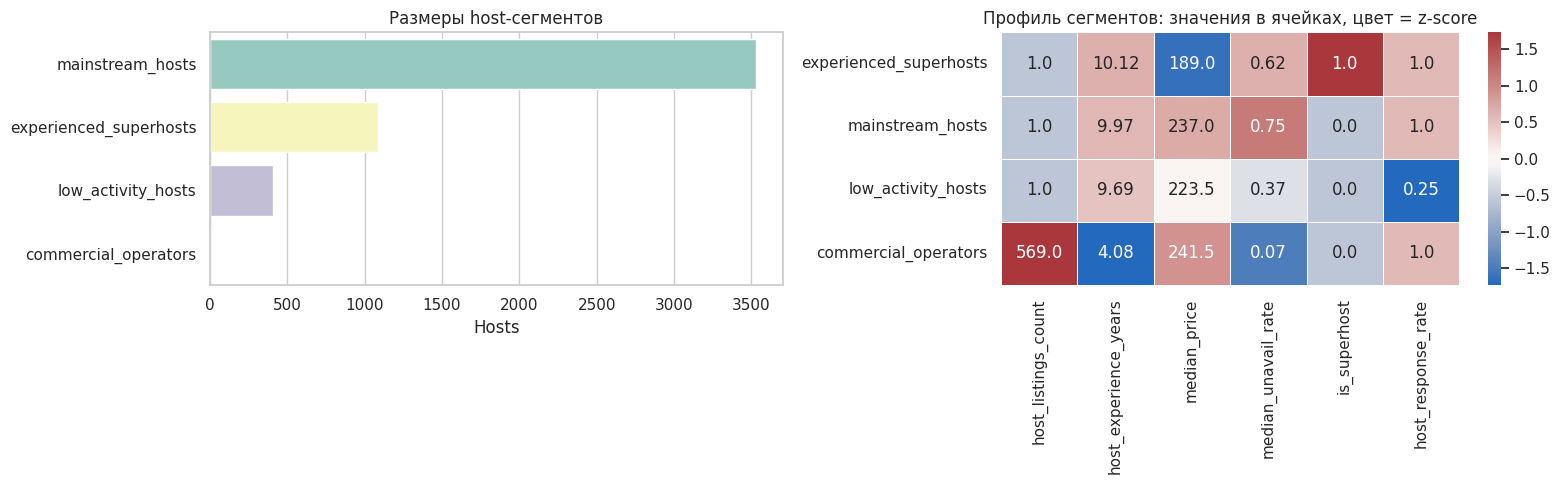

,hosts,median_price,median_occupancy,superhost_share
final_label,,,,
mainstream_hosts,3528,237.0,0.745,0.000
experienced_superhosts,1089,189.0,0.622,1.000
low_activity_hosts,406,223.5,0.374,0.005
commercial_operators,3,241.5,0.071,0.000


In [21]:
# Размеры сегментов и профиль признаков
profile_plot = profile.reset_index()
heat_cols = [
    "host_listings_count", "host_experience_years", "median_price",
    "median_unavail_rate", "is_superhost", "host_response_rate",
]
heat = profile.set_index("label")[heat_cols]
heat_scaled = (heat - heat.mean()) / heat.std(ddof=0).replace(0, np.nan)

fig, ax = plt.subplots(1, 2, figsize=(16, 5))
sns.barplot(data=profile_plot.sort_values("n_hosts", ascending=False), y="label", x="n_hosts", palette="Set3", ax=ax[0])
ax[0].set(title="Размеры host-сегментов", xlabel="Hosts", ylabel="")

sns.heatmap(heat_scaled, annot=heat.round(2), fmt="", cmap="vlag", center=0, linewidths=0.5, ax=ax[1])
ax[1].set(title="Профиль сегментов: значения в ячейках, цвет = z-score", xlabel="", ylabel="")
plt.tight_layout()
plt.show()

segment_mix = (
    hf.groupby("final_label")
    .agg(
        hosts=("host_id", "count"),
        median_price=("mean_price", "median"),
        median_occupancy=("median_unavail_rate", "median"),
        superhost_share=("is_superhost", "mean"),
    )
    .sort_values("hosts", ascending=False)
)
display(segment_mix.round(3))


#### Вывод: интерпретация кластеров

KMeans выделил четыре сегмента хостов с различными стратегиями поведения на рынке Airbnb.

**Mainstream hosts**

- `3528` хостов, около `70%` рынка;
- обычно `1 listing`;
- median price: `237 EUR`;
- высокий `calendar_unavail_rate` (`0.75`).

Это основной массовый сегмент Airbnb Амстердама: небольшие хосты с одним объектом и стабильной активностью в календаре.

**Experienced superhosts**

- `1089` хостов, около `22%` рынка;
- обычно `1 listing`;
- median price: `189 EUR`;
- `calendar_unavail_rate`: `0.62`;
- высокая доля superhost.

Это более опытные хосты с сильной репутацией и хорошей операционной дисциплиной.

**Low activity hosts**

- `406` хостов, около `8%` рынка;
- обычно `1 listing`;
- median price: `224 EUR`;
- низкий `calendar_unavail_rate` (`0.37`);
- низкий response rate.

Вероятно, это менее активные или менее успешные хосты с нестабильной доступностью/активностью.

**Commercial operators**

- всего `3` хоста;
- extremely large portfolios: median `569` listings;
- median price: `241.5 EUR`;
- very low `calendar_unavail_rate` (`0.07`).

Это маленький, но важный commercial/operator сегмент с очень большими портфелями. Его стоит анализировать отдельно, потому что размер группы слишком мал для устойчивых статистических выводов.

**Бизнес-инсайты**

Рынок Airbnb Амстердама почти полностью состоит из небольших hosts с одним listing. Массовый сегмент (`mainstream + experienced`) формирует более `90%` всех хостов.

Крупные commercial operators существуют, но в текущем snapshot представлены всего несколькими аккаунтами, поэтому их влияние лучше оценивать отдельно от массового рынка.


In [22]:
# 3D UMAP-проекция сегментов
if HAS_UMAP:
    emb = umap.UMAP(n_components=3, n_neighbors=30, min_dist=0.15, random_state=SEED).fit_transform(X_scaled)
    plot_df = hf.copy()
    plot_df[["umap_x", "umap_y", "umap_z"]] = emb

    fig = px.scatter_3d(
        plot_df,
        x="umap_x",
        y="umap_y",
        z="umap_z",
        color="final_label",
        opacity=0.7,
        hover_data=["host_listings_count", "host_experience_years", "mean_price", "median_unavail_rate"],
        title="Host Segmentation - 3D UMAP",
    )
    fig.update_traces(marker={"size": 3})
    fig.update_layout(template="plotly_white", height=850, legend_title="Segment")
    fig.show()
else:
    print(f"UMAP visualization пропущена: {UMAP_IMPORT_ERROR}")


## Save Artifacts


In [23]:
# Сохраняем финальные артефакты
out_cols = ["id", "predicted_price", "residual", "residual_z", "category", "fairness_score", "revenue_potential"]
lf[out_cols].to_csv(PROCESSED / "listings_classified.csv", index=False)
hf.to_csv(PROCESSED / "hosts_segmented.csv", index=False)

with open(MODELS / "kmeans_hosts.pkl", "wb") as f:
    pickle.dump({"model": km, "scaler": scaler, "feat_cols": feat_cols}, f)
if HAS_HDBSCAN and hdb is not None:
    with open(MODELS / "hdbscan_hosts.pkl", "wb") as f:
        pickle.dump(hdb, f)

print(f"listings_classified.csv : {len(lf):,} строк")
print(f"hosts_segmented.csv     : {len(hf):,} строк")
print("kmeans_hosts.pkl        : сохранён")
print(f"hdbscan_hosts.pkl       : {'сохранён' if HAS_HDBSCAN and hdb is not None else 'пропущен'}")


listings_classified.csv : 5,844 строк
hosts_segmented.csv     : 5,026 строк
kmeans_hosts.pkl        : сохранён
hdbscan_hosts.pkl       : сохранён


## Итоги ноутбука

Pricing-модель была использована не только для прогнозирования цены, но и как инструмент market intelligence для Airbnb Amsterdam.

### Market Intelligence

На основе residuals между фактической и предсказанной ценой были выделены:
- `137` undervalued listings;
- `371` overpriced listings;
- `5336` fair-priced listings.

Undervalued detector находит объекты с ценой значительно ниже ожидаемого model-based benchmark. Это не готовая инвестиционная рекомендация, а shortlist для дальнейшего ручного анализа: рейтинги между категориями почти не отличаются, а часть объектов требует проверки по reviews, availability и качеству данных.

`fairness_score` показывает близость цены listing к ожидаемой цене модели. Top fair-priced listings можно использовать как benchmark для новых хостов и как baseline для pricing dashboard.

### Revenue Potential

Для каждого listing была рассчитана approximate upper-bound оценка:

```text
revenue_potential = price x occupancy_proxy x 365
```

Топ-районы по median revenue potential:
- `De Baarsjes - Oud-West`;
- `Zuid`;
- `De Pijp - Rivierenbuurt`;
- `Centrum-West`;
- `Westerpark`.

Revenue potential слабо, но логично связан с location: ближе к центру, tourist-зоны и плотные Airbnb-районы слегка повышают оценочный потенциал. Метрика отражает capacity/proxy, а не реальную выручку.

### Host Segmentation

Для сегментации хостов сравнивались `KMeans` и `HDBSCAN`. Финальным методом выбран `KMeans`:
- `k = 4`;
- `silhouette = 0.348`;
- сегменты лучше интерпретируются для бизнес-анализа.

Финальные сегменты:
- `mainstream_hosts`;
- `experienced_superhosts`;
- `low_activity_hosts`;
- `commercial_operators`.

Рынок Airbnb Амстердама почти полностью состоит из небольших hosts с одним listing. Крупные commercial operators есть, но в текущем snapshot составляют крайне малую долю рынка.

### Сохранённые артефакты

- `data/processed/listings_classified.csv`;
- `data/processed/hosts_segmented.csv`;
- `models/kmeans_hosts.pkl`;
- `models/hdbscan_hosts.pkl`.
